Simple Moving Average, Standard Deviation and Bollinger Bands

[*********************100%***********************]  1 of 1 completed


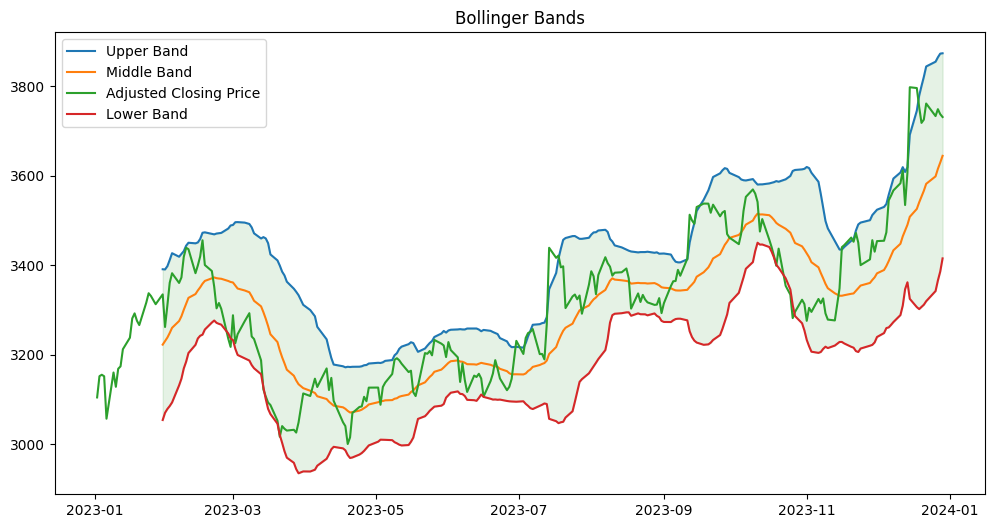

In [72]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

def sma(dat, period: int):
  length = len(dat.index)
  smas = []
  for i in range (0,period-1):
    smas.append(None)
  for i in range (period-1,length):
    sumbox=[]
    for j in range (0,period):
      a = float(dat.iloc[i-j]['Adj Close'][ticker])
      sumbox.append(a)
    sma = (sum(sumbox))/period
    smas.append(sma)

  dat[str(period)+'-day SMA'] = smas
  return dat

def std_dev(dat, column: str, period: int):
  length = len(dat.index)
  std_devs = []
  for i in range(0,period-1):
    std_devs.append(None)
  for i in range(period-1,length):
      dataset1=[]
      for j in range(0,period):
        a = dat.iloc[i-j][column].iloc[0]
        dataset1.append(a)
      avg = sum(dataset1)/len(dataset1)
      sumbo=[]
      for i in range (0,len(dataset1)):
        calc = (dataset1[i] - avg)**2
        sumbo.append(calc)
      std_dev = (sum(sumbo)/len(sumbo))**0.5
      std_devs.append(std_dev)


  dat['Std Dev of '+column]=std_devs
  return dat




ticker = "TCS.NS"
data = yf.download(ticker, start = '2023-01-01', end = '2023-12-31')

data = sma(dat=data,period=20)
data = std_dev(dat=data,column='Adj Close', period = 20)

plt.figure(figsize=(12,6))
plt.title('Bollinger Bands')
plt.plot(data.index, np.array(data['20-day SMA']+2*(np.array(data['Std Dev of Adj Close']))), label='Upper Band')
plt.plot(data.index, np.array(data['20-day SMA']), label='Middle Band')
plt.plot(data.index, np.array(data['Adj Close']), label='Adjusted Closing Price')
plt.plot(data.index, np.array(data['20-day SMA']-2*np.array(data['Std Dev of Adj Close'])), label='Lower Band')
plt.fill_between(data.index, np.array(data['20-day SMA']+2*(np.array(data['Std Dev of Adj Close']))),
                 np.array(data['20-day SMA']-2*np.array(data['Std Dev of Adj Close'])),color='g',alpha=0.1)
plt.legend()
plt.show()





Stochastic Oscillator

[*********************100%***********************]  1 of 1 completed


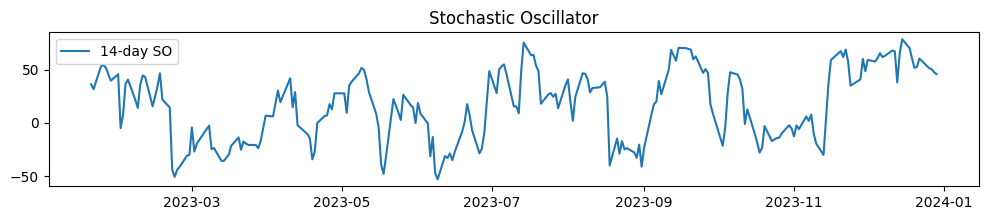

In [73]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

def stochast(dat, period: int):
  length = len(dat.index)
  stochasts = []
  for i in range (0,period-1):
    stochasts.append(None)
  for i in range (period-1,length):
    valueshigh=[]
    valueslow=[]
    for j in range (0,period):
      a = float(dat.iloc[i-j]['High'][ticker])
      b = float(dat.iloc[i-j]['Low'][ticker])
      valueshigh.append(a)
      valueslow.append(b)
    highvalue = max(valueshigh)
    lowvalue = min(valueslow)
    currentvalue = float(dat.iloc[i]['Adj Close'][ticker])
    stochast = ((currentvalue-lowvalue)/(highvalue-lowvalue))*100
    stochasts.append(stochast)

  dat[str(period)+'-day SO']=stochasts
  return dat

ticker = "TCS.NS"
data = yf.download(ticker, start = '2023-01-01', end = '2023-12-31')
data = stochast(dat=data, period=14)

plt.figure(figsize=(12,2))
plt.title('Stochastic Oscillator')
plt.plot(data.index, np.array(data['14-day SO']),label='14-day SO')
plt.legend()
plt.show()



Relative Strength Index

[*********************100%***********************]  1 of 1 completed


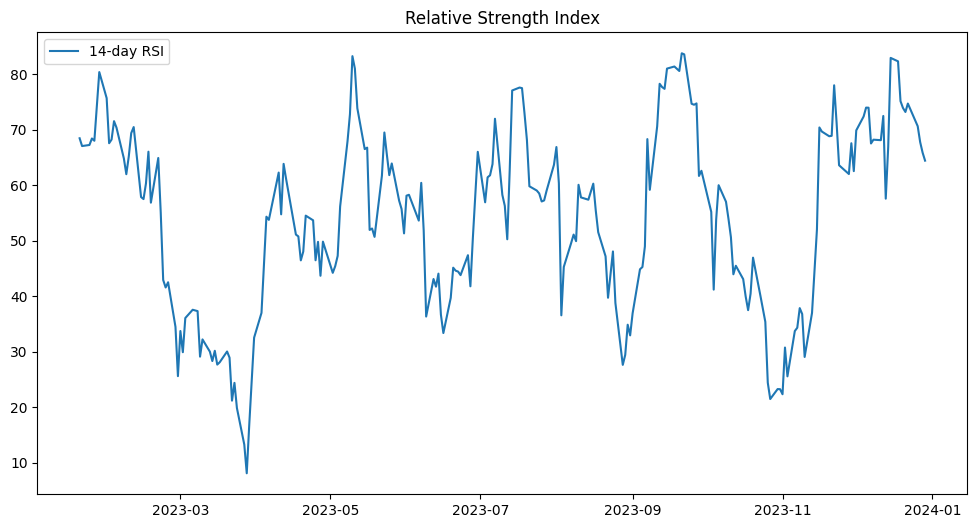

In [74]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math


def rsi(dat,period: int):
  length = len(dat.index)
  gainloss=[0]
  for i in range (1,length):
    a = float(dat.iloc[i-1]['Adj Close'][ticker])
    b = float(dat.iloc[i]['Adj Close'][ticker])
    gainloss.append(b-a)
  gains=[]
  losses=[]
  for i in gainloss:
    if i>=0:
      gains.append(i)
      losses.append(0)
    else:
      gains.append(0)
      losses.append(abs(i))
  rsis=[]
  valuesgains=[]
  valueslosses=[]
  for i in range (0,period-1):
    rsis.append(None)
  for i in range (period-1,length):
    valuesgains=[]
    valueslosses=[]
    for j in range (0,period):
      a = gains[i-j]
      b = losses[i-j]
      valuesgains.append(a)
      valueslosses.append(b)
    avggain = sum(valuesgains)/period
    avgloss = sum(valueslosses)/period
    rs = avggain/avgloss
    rsi = 100-(100/(1+rs))
    rsis.append(rsi)

  dat[str(period)+'-day RSI']=rsis
  return dat

ticker = "TCS.NS"
data = yf.download(ticker, start = '2023-01-01', end = '2023-12-31')
data = rsi(dat=data, period=14)

plt.figure(figsize=(12,6))
plt.title('Relative Strength Index')
plt.plot(data.index, np.array(data['14-day RSI']), label='14-day RSI')
plt.legend()
plt.show()



Exponential Moving Average and Moving Average Convergence Divergence

[*********************100%***********************]  1 of 1 completed


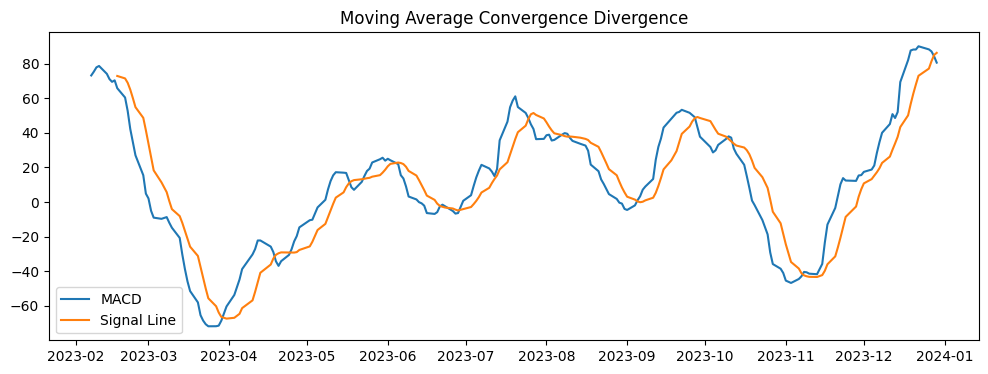

In [75]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

def ema(dat, period: int):
  length = len(dat.index)
  emas=[]
  sumbox=[]
  for i in range(0,period-1):
    emas.append(None)
  for i in range(0,period):
    a = float(dat.iloc[i]['Adj Close'][ticker])
    sumbox.append(a)
  sma = sum(sumbox)/len(sumbox)
  emas.append(sma)
  multiplier = 2/(period+1)
  for i in range(period,length):
    a = float(dat.iloc[i]['Adj Close'][ticker])
    b = emas[i-1]
    ema = a*multiplier + b*(1-multiplier)
    emas.append(ema)

  dat[str(period)+'-day EMA'] = emas
  return dat

def macd(dat1, fastperiod: int, slowperiod: int, signalsmoothper: int):
  dat1 = ema(dat=dat1, period=fastperiod)
  dat1 = ema(dat=dat1, period=slowperiod)

  macd = np.array(dat1[str(fastperiod)+'-day EMA'])-np.array(dat1[str(slowperiod)+'-day EMA'])
  dat1['MACD ({0},{1})'.format(fastperiod,slowperiod)]=macd

  dat1[str(signalsmoothper)+'-day SMA of MACD']=dat1['MACD ({0},{1})'.format(fastperiod,slowperiod)].rolling(signalsmoothper).mean()
  return dat1


ticker = "TCS.NS"
data = yf.download(ticker, start = '2023-01-01', end = '2023-12-31')
data = macd(dat1=data, fastperiod=12, slowperiod=26, signalsmoothper=9)


plt.figure(figsize=(12,4))
plt.title('Moving Average Convergence Divergence')
plt.plot(data.index, np.array(data['MACD (12,26)']), label='MACD')
plt.plot(data.index, np.array(data['9-day SMA of MACD']), label='Signal Line')
plt.legend()
plt.show()


Average True Range

[*********************100%***********************]  1 of 1 completed


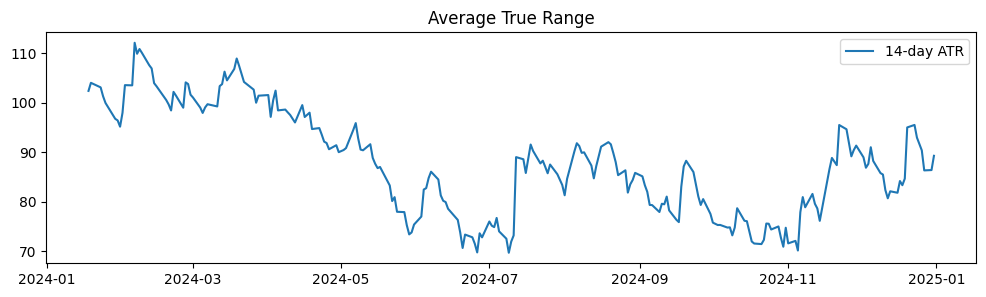

In [76]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

def atr(dat, period: int):
  length = len(dat.index)
  h_l =[]
  h_cp=[None]
  l_cp=[None]
  x = float(dat.iloc[0]['High'][ticker])
  y = float(dat.iloc[0]['Low'][ticker])
  h_l.append(x-y)
  for i in range(1,length):
    a = float(dat.iloc[i]['High'][ticker])
    b = float(dat.iloc[i]['Low'][ticker])
    c = float(dat.iloc[i-1]['Adj Close'][ticker])
    h_l.append(a-b)
    h_cp.append(abs(a-c))
    l_cp.append(abs(b-c))

  trs=[]
  p = float(dat.iloc[0]['High'][ticker])
  q = float(dat.iloc[0]['Low'][ticker])
  trs.append(a-b)
  for i in range(1,length):
    d = []
    d.append(h_l[i])
    d.append(h_cp[i])
    d.append(l_cp[i])
    tr = max(d)
    trs.append(tr)

  atrs=[]
  for i in range(0,period-1):
    sumbox = trs[0:i]
    atr = sum(sumbox)/(i+1)
    atrs.append(atr)
  for i in range(period-1,length):
    m = atrs[i-1]
    n = trs[i]
    atr = ((period-1)*m + n)/period
    atrs.append(atr)

  dat[str(period)+'-day ATR']=atrs
  return dat

ticker = "TCS.NS"
data = yf.download(ticker, start = '2024-01-01', end = '2025-01-01')
length = len(data.index)
data = atr(dat=data, period=14)

plt.figure(figsize=(12,3))
plt.title('Average True Range')
plt.plot(data.index[13:length], np.array(data['14-day ATR'])[13:length], label='14-day ATR')
plt.legend()
plt.show()




Average Directional Index

[*********************100%***********************]  1 of 1 completed


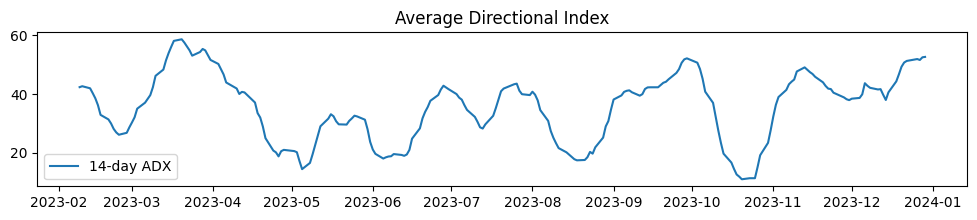

In [77]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

def atr(dat, period: int):
  length = len(dat.index)
  h_l =[]
  h_cp=[None]
  l_cp=[None]
  x = float(dat.iloc[0]['High'][ticker])
  y = float(dat.iloc[0]['Low'][ticker])
  h_l.append(x-y)
  for i in range(1,length):
    a = float(dat.iloc[i]['High'][ticker])
    b = float(dat.iloc[i]['Low'][ticker])
    c = float(dat.iloc[i-1]['Adj Close'][ticker])
    h_l.append(a-b)
    h_cp.append(abs(a-c))
    l_cp.append(abs(b-c))

  trs=[]
  p = float(dat.iloc[0]['High'][ticker])
  q = float(dat.iloc[0]['Low'][ticker])
  trs.append(a-b)
  for i in range(1,length):
    d = []
    d.append(h_l[i])
    d.append(h_cp[i])
    d.append(l_cp[i])
    tr = max(d)
    trs.append(tr)

  atrs=[]
  for i in range(0,period-1):
    sumbox = trs[0:i]
    atr = sum(sumbox)/(i+1)
    atrs.append(atr)
  for i in range(period-1,length):
    m = atrs[i-1]
    n = trs[i]
    atr = ((period-1)*m + n)/period
    atrs.append(atr)

  dat[str(period)+'-day ATR']=atrs
  return dat

def adm(dat1, period: int):
  length = len(data.index)
  dat1=atr(dat=dat1, period=14)
  h_ph=[None]
  l_pl=[None]
  for i in range(1,length):
    a = float(dat1.iloc[i]['High'][ticker])
    b = float(dat1.iloc[i-1]['High'][ticker])
    c = float(dat1.iloc[i]['Low'][ticker])
    d = float(dat1.iloc[i-1]['Low'][ticker])
    h_ph.append(a-b)
    l_pl.append(d-c)
  plusdm=[None]
  minusdm=[None]
  for i in range(1,length):
    if h_ph[i]>l_pl[i] and h_ph[i]>0:
      plusdm.append(h_ph[i])
      minusdm.append(0)
    elif l_pl[i]>h_ph[i] and l_pl[i]>0:
      plusdm.append(0)
      minusdm.append(l_pl[i])
    else:
      plusdm.append(0)
      minusdm.append(0)

  dat1['+DM']=plusdm
  dat1['-DM']=minusdm

  dat1['Smooth+DM']=dat1['+DM'].rolling(period).mean()
  dat1['Smooth-DM']=dat1['-DM'].rolling(period).mean()

  dat1['+DI']=(dat1['Smooth+DM']/dat1['14-day ATR'])*100
  dat1['-DI']=(dat1['Smooth-DM']/dat1['14-day ATR'])*100

  dat1['DX']=abs((dat1['+DI']-dat1['-DI'])/(dat1['+DI']+dat1['-DI']))*100
  dat1[str(period)+'-day ADX']=dat1['DX'].rolling(period).mean()

  dat1 = dat1.drop(columns=['DX','+DI','-DI','Smooth+DM','Smooth-DM','+DM','-DM'])
  return dat1




ticker = "TCS.NS"
data = yf.download(ticker, start = '2023-01-01', end = '2023-12-31')
length = len(data.index)
data = adm(dat1=data, period=14)

plt.figure(figsize=(12,2))
plt.title('Average Directional Index')
plt.plot(data.index, np.array(data['14-day ADX']), label='14-day ADX')
plt.legend()
plt.show()
